In [111]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import os
import sys

from IPython.display import display

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [112]:
# ==========================================
# Project Configuration
# ==========================================

PROJECT_NAME = "Telco Customer Churn ETL"

RAW_DATA_PATH = r"C:\Users\sahana s\Downloads\Telco_customer_churn.xlsx"

OUTPUT_FOLDER = "output"

Path(OUTPUT_FOLDER).mkdir(exist_ok=True)

print("Project :", PROJECT_NAME)
print("Raw File :", RAW_DATA_PATH)
print("Output Folder :", OUTPUT_FOLDER)

Project : Telco Customer Churn ETL
Raw File : C:\Users\sahana s\Downloads\Telco_customer_churn.xlsx
Output Folder : output


In [113]:
# ==========================================
# Helper Function
# ==========================================

def section(title):
    print("\n" + "="*80)
    print(title)
    print("="*80)

In [114]:
# ==========================================
# EXTRACT
# Load Dataset
# ==========================================

section("Loading Dataset")

try:
    df = pd.read_excel(RAW_DATA_PATH)

    print("Dataset loaded successfully.")

except Exception as e:
    print("Error loading dataset")
    print(e)


Loading Dataset
Dataset loaded successfully.


In [115]:
section("Dataset Shape")

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")


Dataset Shape
Rows    : 7,043
Columns : 33


In [116]:
section("First Five Records")

display(df.head())


First Five Records


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [117]:
section("Last Five Records")

display(df.tail())


Last Five Records


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.34,-116.54,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.67,-117.54,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.56,-115.64,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.17,-116.86,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.42,-117.18,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,0,38,5097,NaN


In [118]:
section("Dataset Information")

df.info()


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Servi

In [119]:
section("Column Data Types")

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

display(dtype_df)


Column Data Types


,Column,Data Type
CustomerID,CustomerID,str
Count,Count,int64
Country,Country,str
State,State,str
City,City,str
Zip Code,Zip Code,int64
Lat Long,Lat Long,str
Latitude,Latitude,float64
Longitude,Longitude,float64
Gender,Gender,str


In [120]:
section("Column Names")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")


Column Names
01. CustomerID
02. Count
03. Country
04. State
05. City
06. Zip Code
07. Lat Long
08. Latitude
09. Longitude
10. Gender
11. Senior Citizen
12. Partner
13. Dependents
14. Tenure Months
15. Phone Service
16. Multiple Lines
17. Internet Service
18. Online Security
19. Online Backup
20. Device Protection
21. Tech Support
22. Streaming TV
23. Streaming Movies
24. Contract
25. Paperless Billing
26. Payment Method
27. Monthly Charges
28. Total Charges
29. Churn Label
30. Churn Value
31. Churn Score
32. CLTV
33. Churn Reason


In [121]:
section("Numerical Summary")

display(df.describe())


Numerical Summary


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,1.00,93521.96,36.28,-119.80,32.37,64.76,0.27,58.70,4400.30
std,0.00,1865.79,2.46,2.16,24.56,30.09,0.44,21.53,1183.06
min,1.00,90001.00,32.56,-124.30,0.00,18.25,0.00,5.00,2003.00
25%,1.00,92102.00,34.03,-121.82,9.00,35.50,0.00,40.00,3469.00
50%,1.00,93552.00,36.39,-119.73,29.00,70.35,0.00,61.00,4527.00
75%,1.00,95351.00,38.22,-118.04,55.00,89.85,1.00,75.00,5380.50
max,1.00,96161.00,41.96,-114.19,72.00,118.75,1.00,100.00,6500.00


In [122]:
section("Complete Summary")

display(df.describe(include="all").T)


Complete Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.00,NaN,NaN,NaN,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.00,NaN,NaN,NaN,93521.96,1865.79,90001.00,92102.00,93552.00,95351.00,96161.00
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.00,NaN,NaN,NaN,36.28,2.46,32.56,34.03,36.39,38.22,41.96
Longitude,7043.00,NaN,NaN,NaN,-119.80,2.16,-124.30,-121.82,-119.73,-118.04,-114.19
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
section("Column Categories")

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns")

print("-"*40)

for col in numerical_columns:
    print(col)

print("\n")

print("Categorical Columns")

print("-"*40)

for col in categorical_columns:
    print(col)


Column Categories
Numerical Columns
----------------------------------------
Count
Zip Code
Latitude
Longitude
Tenure Months
Monthly Charges
Churn Value
Churn Score
CLTV


Categorical Columns
----------------------------------------
CustomerID
Country
State
City
Lat Long
Gender
Senior Citizen
Partner
Dependents
Phone Service
Multiple Lines
Internet Service
Online Security
Online Backup
Device Protection
Tech Support
Streaming TV
Streaming Movies
Contract
Paperless Billing
Payment Method
Total Charges
Churn Label
Churn Reason


In [124]:
def section(title):
    print(f"\n{'='*50}\n{title}\n{'='*50}")


In [125]:
section("Dataset Overview")

profile = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null": df.notnull().sum().values,
    "Null": df.isnull().sum().values,
    "Unique": df.nunique().values,
    "Duplicate Values": df.apply(lambda col: col.duplicated().sum()).values
})

display(profile)



Dataset Overview


,Column,Data Type,Non-Null,Null,Unique,Duplicate Values
0,CustomerID,str,7043,0,7043,0
1,Count,int64,7043,0,1,7042
2,Country,str,7043,0,1,7042
3,State,str,7043,0,1,7042
4,City,str,7043,0,1129,5914
5,Zip Code,int64,7043,0,1652,5391
6,Lat Long,str,7043,0,1652,5391
7,Latitude,float64,7043,0,1652,5391
8,Longitude,float64,7043,0,1651,5392
9,Gender,str,7043,0,2,7041


In [126]:
section("Missing Value Summary")

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing = missing.sort_values("Missing Values", ascending=False)

display(missing)


Missing Value Summary


,Missing Values,Percentage
Churn Reason,5174,73.46
CustomerID,0,0.00
Count,0,0.00
State,0,0.00
Country,0,0.00
Zip Code,0,0.00
Lat Long,0,0.00
Latitude,0,0.00
City,0,0.00
Gender,0,0.00


In [127]:
section("Unique Values")

unique_df = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

display(unique_df.sort_values("Unique Values"))


Unique Values


,Column,Unique Values
1,Count,1
2,Country,1
3,State,1
14,Phone Service,2
12,Dependents,2
11,Partner,2
10,Senior Citizen,2
9,Gender,2
29,Churn Value,2
24,Paperless Billing,2


In [128]:
section("Cardinality Analysis")

cardinality = pd.DataFrame({
    "Column": df.columns,
    "Unique Count": df.nunique(),
    "Cardinality %": round(df.nunique()/len(df)*100,2)
})

display(cardinality.sort_values("Cardinality %", ascending=False))


Cardinality Analysis


,Column,Unique Count,Cardinality %
CustomerID,CustomerID,7043,100.00
Total Charges,Total Charges,6531,92.73
CLTV,CLTV,3438,48.81
Lat Long,Lat Long,1652,23.46
Latitude,Latitude,1652,23.46
Zip Code,Zip Code,1652,23.46
Longitude,Longitude,1651,23.44
Monthly Charges,Monthly Charges,1585,22.50
City,City,1129,16.03
Churn Score,Churn Score,85,1.21


In [129]:
section("Numerical Profiling")

display(df[numerical_columns].describe().T)


Numerical Profiling


,count,mean,std,min,25%,50%,75%,max
Count,7043.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Zip Code,7043.00,93521.96,1865.79,90001.00,92102.00,93552.00,95351.00,96161.00
Latitude,7043.00,36.28,2.46,32.56,34.03,36.39,38.22,41.96
Longitude,7043.00,-119.80,2.16,-124.30,-121.82,-119.73,-118.04,-114.19
Tenure Months,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
Monthly Charges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
Churn Value,7043.00,0.27,0.44,0.00,0.00,0.00,1.00,1.00
Churn Score,7043.00,58.70,21.53,5.00,40.00,61.00,75.00,100.00
CLTV,7043.00,4400.30,1183.06,2003.00,3469.00,4527.00,5380.50,6500.00


In [130]:
section("Categorical Profiling")

display(df[categorical_columns].describe().T)


Categorical Profiling


,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"33.964131, -118.272783",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [131]:
section("Frequency Distribution")

for col in categorical_columns:

    print("="*60)
    print(col)
    print("="*60)

    display(df[col].value_counts(dropna=False))

    print()


Frequency Distribution
CustomerID


CustomerID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64


Country


Country
United States    7043
Name: count, dtype: int64


State


...

Total Charges
20.20      11
           11
19.75       9
19.90       8
19.65       8
           ..
1419.40     1
1990.50     1
7362.90     1
346.45      1
6844.50     1
Name: count, Length: 6531, dtype: int64


Churn Label


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


Churn Reason


Churn Reason
NaN                                          5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Limited range of services                      44
Lack of affordable download/upload speed       44
Long distance charges                          44
Poor expertise of phone support                20
Poor expertise of online support     

In [132]:
section("Churn Distribution")

display(df["Churn Label"].value_counts())

display(df["Churn Label"].value_counts(normalize=True).mul(100).round(2))


Churn Distribution


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn Label
No    73.46
Yes   26.54
Name: proportion, dtype: float64

In [133]:
section("Gender Distribution")

display(df["Gender"].value_counts())

display(df["Gender"].value_counts(normalize=True).mul(100).round(2))


Gender Distribution


Gender
Male      3555
Female    3488
Name: count, dtype: int64

Gender
Male     50.48
Female   49.52
Name: proportion, dtype: float64

In [134]:
section("Contract Distribution")

display(df["Contract"].value_counts())

display(df["Contract"].value_counts(normalize=True).mul(100).round(2))


Contract Distribution


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Contract
Month-to-month   55.02
Two year         24.07
One year         20.91
Name: proportion, dtype: float64

In [135]:
section("Internet Service")

display(df["Internet Service"].value_counts())

display(df["Internet Service"].value_counts(normalize=True).mul(100).round(2))


Internet Service


Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Internet Service
Fiber optic   43.96
DSL           34.37
No            21.67
Name: proportion, dtype: float64

In [136]:
section("Payment Method")

display(df["Payment Method"].value_counts())

display(df["Payment Method"].value_counts(normalize=True).mul(100).round(2))


Payment Method


Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Payment Method
Electronic check            33.58
Mailed check                22.89
Bank transfer (automatic)   21.92
Credit card (automatic)     21.61
Name: proportion, dtype: float64

In [137]:
section("Skewness")

skew_df = pd.DataFrame({
    "Column": numerical_columns,
    "Skewness": [df[col].skew() for col in numerical_columns]
})

display(skew_df)


Skewness


,Column,Skewness
0,Count,0.00
1,Zip Code,-0.25
2,Latitude,0.30
3,Longitude,-0.04
4,Tenure Months,0.24
5,Monthly Charges,-0.22
6,Churn Value,1.06
7,Churn Score,-0.09
8,CLTV,-0.31


In [138]:
section("Correlation Matrix")

corr = df[numerical_columns].drop(columns=["Zip Code"]).corr()

display(corr.round(2))


Correlation Matrix


,Count,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,NaN,1.00,-0.88,-0.00,-0.02,-0.00,-0.01,0.00
Longitude,NaN,-0.88,1.00,-0.00,0.02,0.00,0.00,0.00
Tenure Months,NaN,-0.00,-0.00,1.00,0.25,-0.35,-0.22,0.40
Monthly Charges,NaN,-0.02,0.02,0.25,1.00,0.19,0.13,0.10
Churn Value,NaN,-0.00,0.00,-0.35,0.19,1.00,0.66,-0.13
Churn Score,NaN,-0.01,0.00,-0.22,0.13,0.66,1.00,-0.08
CLTV,NaN,0.00,0.00,0.40,0.10,-0.13,-0.08,1.00


In [139]:
section("Memory Optimization Check")

memory_before = df.memory_usage(deep=True).sum()/1024**2

print(f"Current Memory Usage : {memory_before:.2f} MB")


Memory Optimization Check
Current Memory Usage : 3.05 MB


In [140]:
section("Initial Profiling Findings")

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print(f"Missing Values : {df.isnull().sum().sum()}")

print(f"Duplicate Rows : {df.duplicated().sum()}")

print(f"Duplicate Customer IDs : {df['CustomerID'].duplicated().sum()}")

print(f"Numerical Columns : {len(numerical_columns)}")

print(f"Categorical Columns : {len(categorical_columns)}")


Initial Profiling Findings
Rows : 7043
Columns : 33
Missing Values : 5174
Duplicate Rows : 0
Duplicate Customer IDs : 0
Numerical Columns : 9
Categorical Columns : 24


In [141]:
section("Missing Value Report")

missing_report = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Percentage": (df.isna().mean() * 100).round(2)
})

missing_report = missing_report[missing_report["Missing Values"] > 0]
display(missing_report)


Missing Value Report


,Missing Values,Percentage
Churn Reason,5174,73.46


In [142]:
section("Business Validation - Churn Reason")

print("Customers with Churn = Yes")
print(df[df["Churn Label"] == "Yes"]["Churn Reason"].isna().sum())

print()

print("Customers with Churn = No")
print(df[df["Churn Label"] == "No"]["Churn Reason"].isna().sum())


Business Validation - Churn Reason
Customers with Churn = Yes
0

Customers with Churn = No
5174


In [143]:
section("Duplicate Validation")

print("Duplicate Rows :", df.duplicated().sum())

print("Duplicate Customer IDs :", df["CustomerID"].duplicated().sum())


Duplicate Validation
Duplicate Rows : 0
Duplicate Customer IDs : 0


In [144]:
section("Leading / Trailing Spaces")

object_cols = df.select_dtypes(include=["object", "string"]).columns

whitespace_report = {}

for col in object_cols:
    count = df[col].astype(str).str.startswith(" ").sum() + \
            df[col].astype(str).str.endswith(" ").sum()

    whitespace_report[col] = count

whitespace_df = pd.DataFrame.from_dict(
    whitespace_report,
    orient="index",
    columns=["Whitespace Count"]
)

display(whitespace_df.sort_values("Whitespace Count", ascending=False))


Leading / Trailing Spaces


,Whitespace Count
Total Charges,22
CustomerID,0
State,0
Country,0
Lat Long,0
Gender,0
Senior Citizen,0
City,0
Partner,0
Dependents,0


In [145]:
section("Empty String Check")

empty_report = {}

for col in object_cols:
    empty_report[col] = (df[col].astype(str).str.strip() == "").sum()

display(pd.DataFrame.from_dict(
    empty_report,
    orient="index",
    columns=["Empty Strings"]
).sort_values("Empty Strings", ascending=False))


Empty String Check


,Empty Strings
Total Charges,11
CustomerID,0
State,0
Country,0
Lat Long,0
Gender,0
Senior Citizen,0
City,0
Partner,0
Dependents,0


In [146]:
section("Total Charges Validation")

total_numeric = pd.to_numeric(df["Total Charges"], errors="coerce")

print("Invalid Values :", total_numeric.isna().sum())

display(df.loc[total_numeric.isna(),
               ["CustomerID", "Total Charges"]].head(20))


Total Charges Validation
Invalid Values : 11


,CustomerID,Total Charges
2234,4472-LVYGI,
2438,3115-CZMZD,
2568,5709-LVOEQ,
2667,4367-NUYAO,
2856,1371-DWPAZ,
4331,7644-OMVMY,
4687,3213-VVOLG,
5104,2520-SGTTA,
5719,2923-ARZLG,
6772,4075-WKNIU,


In [147]:
section("Constant Columns")

constant_cols = []

for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        constant_cols.append(col)

print(constant_cols)


Constant Columns
['Count', 'Country', 'State']


In [148]:
section("Latitude / Longitude Validation")

invalid_lat = df[
    (df["Latitude"] < -90) |
    (df["Latitude"] > 90)
]

invalid_lon = df[
    (df["Longitude"] < -180) |
    (df["Longitude"] > 180)
]

print("Invalid Latitude :", len(invalid_lat))
print("Invalid Longitude :", len(invalid_lon))


Latitude / Longitude Validation
Invalid Latitude : 0
Invalid Longitude : 0


In [149]:
section("Numeric Range Validation")

checks = {
    "Negative Monthly Charges":
        (df["Monthly Charges"] < 0).sum(),

    "Negative CLTV":
        (df["CLTV"] < 0).sum(),

    "Negative Churn Score":
        (df["Churn Score"] < 0).sum(),

    "Negative Tenure":
        (df["Tenure Months"] < 0).sum()
}

display(pd.DataFrame(
    checks.items(),
    columns=["Validation", "Count"]
))


Numeric Range Validation


,Validation,Count
0,Negative Monthly Charges,0
1,Negative CLTV,0
2,Negative Churn Score,0
3,Negative Tenure,0


In [150]:
section("Categorical Validation")

yes_no_columns = [
    "Partner",
    "Dependents",
    "Phone Service",
    "Paperless Billing"
]

for col in yes_no_columns:

    print("=" * 60)
    print(col)

    print(df[col].value_counts(dropna=False))
    print()


Categorical Validation
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

Phone Service
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

Paperless Billing
Paperless Billing
Yes    4171
No     2872
Name: count, dtype: int64



In [151]:
section("Data Quality Summary")

quality_summary = pd.DataFrame({

    "Metric": [

        "Rows",

        "Columns",

        "Missing Cells",

        "Duplicate Rows",

        "Duplicate Customer IDs",

        "Constant Columns"

    ],

    "Value": [

        len(df),

        len(df.columns),

        df.isna().sum().sum(),

        df.duplicated().sum(),

        df["CustomerID"].duplicated().sum(),

        len(constant_cols)

    ]

})

display(quality_summary)


Data Quality Summary


,Metric,Value
0,Rows,7043
1,Columns,33
2,Missing Cells,5174
3,Duplicate Rows,0
4,Duplicate Customer IDs,0
5,Constant Columns,3


In [152]:
section("Create Working Copy")

df_clean = df.copy()

print("Working copy created successfully.")
print(df_clean.shape)


Create Working Copy
Working copy created successfully.
(7043, 33)


In [153]:
section("Remove Unnecessary Columns")

columns_to_remove = [
    "Count",
    "Country",
    "State",
    "Lat Long"
]

existing_columns = [col for col in columns_to_remove if col in df_clean.columns]

df_clean.drop(columns=existing_columns, inplace=True)

print("Removed Columns:")
for col in existing_columns:
    print(f"✓ {col}")

print("\nCurrent Shape:", df_clean.shape)


Remove Unnecessary Columns
Removed Columns:
✓ Count
✓ Country
✓ State
✓ Lat Long

Current Shape: (7043, 29)


In [154]:
section("Trim Whitespace")

text_columns = df_clean.select_dtypes(include=["object", "string"]).columns

for col in text_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("Whitespace removed successfully.")


Trim Whitespace
Whitespace removed successfully.


In [155]:
section("Restore Missing Values")

df_clean.replace(
    ["", "nan", "None"],
    np.nan,
    inplace=True
)

print("Missing values restored.")


Restore Missing Values
Missing values restored.


In [156]:
section("Convert Total Charges")

df_clean["Total Charges"] = pd.to_numeric(
    df_clean["Total Charges"],
    errors="coerce"
)

print(df_clean["Total Charges"].dtype)

print()

print("Missing after conversion:")

print(df_clean["Total Charges"].isna().sum())


Convert Total Charges
float64

Missing after conversion:
11


In [157]:
section("Handle Missing Total Charges")

missing_before = df_clean["Total Charges"].isna().sum()

df_clean["Total Charges"] = df_clean["Total Charges"].fillna(0)

missing_after = df_clean["Total Charges"].isna().sum()

print("Missing Before :", missing_before)
print("Missing After  :", missing_after)


Handle Missing Total Charges
Missing Before : 11
Missing After  : 0


In [158]:
section("Standardize Text")

categorical_columns = df_clean.select_dtypes(
    include=["object", "string"]
).columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].str.strip()

print("Categorical text standardized.")


Standardize Text
Categorical text standardized.


In [159]:
section("Optimize Data Types")

int_columns = df_clean.select_dtypes(include="int64").columns

for col in int_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        downcast="integer"
    )

float_columns = df_clean.select_dtypes(include="float64").columns

for col in float_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        downcast="float"
    )

print(df_clean.dtypes)


Optimize Data Types
CustomerID               str
City                     str
Zip Code               int32
Latitude             float32
Longitude            float32
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months           int8
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float32
Total Charges        float32
Churn Label              str
Churn Value             int8
Churn Score             int8
CLTV                   int16
Churn Reason             str
dtype: object


In [160]:
section("Transformation Validation")

print("Shape :", df_clean.shape)

print()

print("Missing Values")

display(df_clean.isna().sum())

print()

print("Duplicate Rows :", df_clean.duplicated().sum())

print()

print("Duplicate Customer IDs :")

print(df_clean["CustomerID"].duplicated().sum())


Transformation Validation
Shape : (7043, 29)

Missing Values


CustomerID              0
City                    0
Zip Code                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


Duplicate Rows : 0

Duplicate Customer IDs :
0


In [161]:
section("Before vs After")

comparison = pd.DataFrame({

    "Metric": [

        "Rows",

        "Columns",

        "Missing Values",

        "Memory (MB)"

    ],

    "Before": [

        df.shape[0],

        df.shape[1],

        df.isna().sum().sum(),

        round(df.memory_usage(deep=True).sum()/1024**2,2)

    ],

    "After": [

        df_clean.shape[0],

        df_clean.shape[1],

        df_clean.isna().sum().sum(),

        round(df_clean.memory_usage(deep=True).sum()/1024**2,2)

    ]

})

display(comparison)


Before vs After


,Metric,Before,After
0,Rows,7043.00,7043.00
1,Columns,33.00,29.00
2,Missing Values,5174.00,5174.00
3,Memory (MB),3.05,2.08


In [162]:
df_clean.isna().sum()

CustomerID              0
City                    0
Zip Code                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [163]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   City               7043 non-null   str    
 2   Zip Code           7043 non-null   int32  
 3   Latitude           7043 non-null   float32
 4   Longitude          7043 non-null   float32
 5   Gender             7043 non-null   str    
 6   Senior Citizen     7043 non-null   str    
 7   Partner            7043 non-null   str    
 8   Dependents         7043 non-null   str    
 9   Tenure Months      7043 non-null   int8   
 10  Phone Service      7043 non-null   str    
 11  Multiple Lines     7043 non-null   str    
 12  Internet Service   7043 non-null   str    
 13  Online Security    7043 non-null   str    
 14  Online Backup      7043 non-null   str    
 15  Device Protection  7043 non-null   str    
 16  Tech Support       7043 non-null   

In [164]:
section("CustomerID Validation")

duplicate_ids = df_clean["CustomerID"].duplicated().sum()

print(f"Duplicate Customer IDs : {duplicate_ids}")

assert duplicate_ids == 0, "Duplicate Customer IDs Found!"

print("Validation Passed")


CustomerID Validation
Duplicate Customer IDs : 0
Validation Passed


In [165]:
section("Churn Consistency Validation")

invalid_churn = df_clean[
    ((df_clean["Churn Label"] == "Yes") & (df_clean["Churn Value"] != 1)) |
    ((df_clean["Churn Label"] == "No") & (df_clean["Churn Value"] != 0))
]

print(f"Inconsistent Records : {len(invalid_churn)}")

display(invalid_churn.head())


Churn Consistency Validation
Inconsistent Records : 0


,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [166]:
section("Churn Reason Validation")

invalid_reason = df_clean[
    (df_clean["Churn Label"] == "No") &
    (df_clean["Churn Reason"].notna())
]

print("Invalid Records :", len(invalid_reason))

display(invalid_reason.head())


Churn Reason Validation
Invalid Records : 0


,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [167]:
section("Internet Service Validation")

internet_cols = [

    "Online Security",

    "Online Backup",

    "Device Protection",

    "Tech Support",

    "Streaming TV",

    "Streaming Movies"

]

mask = df_clean["Internet Service"] == "No"

invalid = pd.DataFrame()

for col in internet_cols:

    invalid = pd.concat([
        invalid,
        df_clean[mask & (df_clean[col] != "No internet service")]
    ])

print("Invalid Records :", len(invalid))

display(invalid.head())


Internet Service Validation
Invalid Records : 0


,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [168]:
section("Phone Service Validation")

phone_invalid = df_clean[
    (df_clean["Phone Service"] == "No") &
    (df_clean["Multiple Lines"] != "No phone service")
]

print("Invalid Records :", len(phone_invalid))

display(phone_invalid.head())


Phone Service Validation
Invalid Records : 0


,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [169]:
section("Tenure Validation")

invalid_tenure = df_clean[
    (df_clean["Tenure Months"] < 0)
]

print("Invalid Records :", len(invalid_tenure))


Tenure Validation
Invalid Records : 0


In [170]:
section("Monthly Charges Validation")

invalid_monthly = df_clean[
    df_clean["Monthly Charges"] < 0
]

print("Invalid Records :", len(invalid_monthly))


Monthly Charges Validation
Invalid Records : 0


In [171]:
section("Total Charges Validation")

invalid_total = df_clean[
    df_clean["Total Charges"] < 0
]

print("Invalid Records :", len(invalid_total))


Total Charges Validation
Invalid Records : 0


In [172]:
section("CLTV Validation")

invalid_cltv = df_clean[
    df_clean["CLTV"] < 0
]

print("Invalid Records :", len(invalid_cltv))


CLTV Validation
Invalid Records : 0


In [173]:
section("Churn Score Validation")

invalid_score = df_clean[
    (df_clean["Churn Score"] < 0) |
    (df_clean["Churn Score"] > 100)
]

print("Invalid Records :", len(invalid_score))


Churn Score Validation
Invalid Records : 0


In [174]:
section("Categorical Value Validation")

for col in categorical_columns:

    print("="*70)

    print(col)

    print(sorted(df_clean[col].dropna().unique()))

    print()


Categorical Value Validation
CustomerID
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-

In [175]:
section("Business Rule Validation Report")

validation = {

    "Duplicate Customer IDs": duplicate_ids,

    "Invalid Churn Mapping": len(invalid_churn),

    "Invalid Churn Reason": len(invalid_reason),

    "Internet Rule Violations": len(invalid),

    "Phone Rule Violations": len(phone_invalid),

    "Invalid Tenure": len(invalid_tenure),

    "Invalid Monthly Charges": len(invalid_monthly),

    "Invalid Total Charges": len(invalid_total),

    "Invalid CLTV": len(invalid_cltv),

    "Invalid Churn Score": len(invalid_score)

}

validation_df = pd.DataFrame(
    validation.items(),
    columns=["Validation", "Failed Records"]
)

display(validation_df)


Business Rule Validation Report


,Validation,Failed Records
0,Duplicate Customer IDs,0
1,Invalid Churn Mapping,0
2,Invalid Churn Reason,0
3,Internet Rule Violations,0
4,Phone Rule Violations,0
5,Invalid Tenure,0
6,Invalid Monthly Charges,0
7,Invalid Total Charges,0
8,Invalid CLTV,0
9,Invalid Churn Score,0


In [176]:
section("Feature Engineering")

print(f"Columns Before : {df_clean.shape[1]}")


Feature Engineering
Columns Before : 29


In [177]:
section("Create Tenure Group")

df_clean["Tenure Group"] = pd.cut(
    df_clean["Tenure Months"],
    bins=[-1,12,24,48,72],
    labels=[
        "New Customer",
        "Short Term",
        "Medium Term",
        "Long Term"
    ]
)

display(df_clean["Tenure Group"].value_counts())


Create Tenure Group


Tenure Group
Long Term       2239
New Customer    2186
Medium Term     1594
Short Term      1024
Name: count, dtype: int64

In [178]:
section("Monthly Charge Category")

df_clean["Monthly Charge Category"] = pd.qcut(
    df_clean["Monthly Charges"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

display(df_clean["Monthly Charge Category"].value_counts())


Monthly Charge Category


Monthly Charge Category
Medium       1766
Low          1762
Very High    1758
High         1757
Name: count, dtype: int64

In [179]:
section("CLTV Category")

df_clean["CLTV Category"] = pd.qcut(
    df_clean["CLTV"],
    q=4,
    labels=[
        "Bronze",
        "Silver",
        "Gold",
        "Platinum"
    ]
)

display(df_clean["CLTV Category"].value_counts())


CLTV Category


CLTV Category
Bronze      1763
Platinum    1761
Gold        1760
Silver      1759
Name: count, dtype: int64

In [180]:
section("Total Services")

service_columns = [

    "Phone Service",

    "Multiple Lines",

    "Online Security",

    "Online Backup",

    "Device Protection",

    "Tech Support",

    "Streaming TV",

    "Streaming Movies"

]

df_clean["Total Services"] = (
    df_clean[service_columns]
    .isin(["Yes"])
    .sum(axis=1)
)

display(df_clean["Total Services"].describe())


Total Services


count   7043.00
mean       3.36
std        2.06
min        0.00
25%        1.00
50%        3.00
75%        5.00
max        8.00
Name: Total Services, dtype: float64

In [181]:
section("Streaming Services Count")

stream_cols = [

    "Streaming TV",

    "Streaming Movies"

]

df_clean["Streaming Services Count"] = (

    df_clean[stream_cols]

    .eq("Yes")

    .sum(axis=1)

)

display(df_clean["Streaming Services Count"].value_counts())


Streaming Services Count


Streaming Services Count
0    3544
2    1940
1    1559
Name: count, dtype: int64

In [182]:
section("Security Services Count")

security_cols = [

    "Online Security",

    "Online Backup",

    "Device Protection",

    "Tech Support"

]

df_clean["Security Services Count"] = (

    df_clean[security_cols]

    .eq("Yes")

    .sum(axis=1)

)

display(df_clean["Security Services Count"].value_counts())


Security Services Count


Security Services Count
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64

In [183]:
section("Auto Payment Flag")

df_clean["Auto Payment"] = np.where(

    df_clean["Payment Method"].isin([

        "Bank transfer (automatic)",

        "Credit card (automatic)"

    ]),

    "Yes",

    "No"

)

display(df_clean["Auto Payment"].value_counts())


Auto Payment Flag


Auto Payment
No     3977
Yes    3066
Name: count, dtype: int64

In [184]:
section("Contract Duration")

contract_map = {

    "Month-to-month":"Monthly",

    "One year":"Annual",

    "Two year":"Biannual"

}

df_clean["Contract Duration"] = df_clean["Contract"].map(contract_map)

display(df_clean["Contract Duration"].value_counts())


Contract Duration


Contract Duration
Monthly     3875
Biannual    1695
Annual      1473
Name: count, dtype: int64

In [185]:
section("Average Monthly Spend")

df_clean["Average Monthly Spend"] = np.where(

    df_clean["Tenure Months"]==0,

    df_clean["Monthly Charges"],

    df_clean["Total Charges"]/df_clean["Tenure Months"]

)

display(df_clean["Average Monthly Spend"].describe())


Average Monthly Spend


count   7043.00
mean      64.76
std       30.19
min       13.77
25%       35.94
50%       70.34
75%       90.17
max      121.40
Name: Average Monthly Spend, dtype: float64

In [186]:
section("Customer Relationship")

df_clean["Customer Age"] = np.where(

    df_clean["Tenure Months"]>=48,

    "Loyal",

    np.where(

        df_clean["Tenure Months"]>=24,

        "Established",

        "New"

    )

)

display(df_clean["Customer Age"].value_counts())


Customer Relationship


Customer Age
New            3116
Loyal          2303
Established    1624
Name: count, dtype: int64

In [187]:
section("High Value Customer")

median_cltv = df_clean["CLTV"].median()

df_clean["High Value Customer"] = np.where(

    df_clean["CLTV"]>=median_cltv,

    "Yes",

    "No"

)

display(df_clean["High Value Customer"].value_counts())


High Value Customer


High Value Customer
Yes    3522
No     3521
Name: count, dtype: int64

In [188]:
section("Churn Risk Category")

df_clean["Churn Risk"] = pd.cut(

    df_clean["Churn Score"],

    bins=[0,25,50,75,100],

    include_lowest=True,

    labels=[

        "Low",

        "Moderate",

        "High",

        "Critical"

    ]

)

display(df_clean["Churn Risk"].value_counts())


Churn Risk Category


Churn Risk
High        2696
Moderate    2090
Critical    1751
Low          506
Name: count, dtype: int64

In [189]:
section("Churn Risk Category")

df_clean["Churn Risk"] = pd.cut(

    df_clean["Churn Score"],

    bins=[0,25,50,75,100],

    include_lowest=True,

    labels=[

        "Low",

        "Moderate",

        "High",

        "Critical"

    ]

)

display(df_clean["Churn Risk"].value_counts())


Churn Risk Category


Churn Risk
High        2696
Moderate    2090
Critical    1751
Low          506
Name: count, dtype: int64

In [190]:
section("Senior Citizen Flag")

df_clean["Senior Citizen Flag"] = np.where(

    df_clean["Senior Citizen"]=="Yes",

    1,

    0

)

display(df_clean["Senior Citizen Flag"].value_counts())


Senior Citizen Flag


Senior Citizen Flag
0    5901
1    1142
Name: count, dtype: int64

In [191]:
section("Internet User")

df_clean["Internet User"] = np.where(

    df_clean["Internet Service"]=="No",

    "No",

    "Yes"

)

display(df_clean["Internet User"].value_counts())


Internet User


Internet User
Yes    5517
No     1526
Name: count, dtype: int64

In [192]:
section("Feature Engineering Summary")

new_features = [

    "Tenure Group",

    "Monthly Charge Category",

    "CLTV Category",

    "Total Services",

    "Streaming Services Count",

    "Security Services Count",

    "Auto Payment",

    "Contract Duration",

    "Average Monthly Spend",

    "Customer Age",

    "High Value Customer",

    "Churn Risk",

    "Senior Citizen Flag",

    "Internet User"

]

print(f"New Features Created : {len(new_features)}")

for feature in new_features:
    print(f"✓ {feature}")

print("\nDataset Shape:")
print(df_clean.shape)


Feature Engineering Summary
New Features Created : 14
✓ Tenure Group
✓ Monthly Charge Category
✓ CLTV Category
✓ Total Services
✓ Streaming Services Count
✓ Security Services Count
✓ Auto Payment
✓ Contract Duration
✓ Average Monthly Spend
✓ Customer Age
✓ High Value Customer
✓ Churn Risk
✓ Senior Citizen Flag
✓ Internet User

Dataset Shape:
(7043, 43)


In [193]:
section("Final Dataset Overview")

print(f"Rows    : {df_clean.shape[0]:,}")
print(f"Columns : {df_clean.shape[1]}")

display(df_clean.head())


Final Dataset Overview
Rows    : 7,043
Columns : 43


,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Tenure Group,Monthly Charge Category,CLTV Category,Total Services,Streaming Services Count,Security Services Count,Auto Payment,Contract Duration,Average Monthly Spend,Customer Age,High Value Customer,Churn Risk,Senior Citizen Flag,Internet User
0,3668-QPYBK,Los Angeles,90003,33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,New Customer,Medium,Bronze,3,0,2,No,Monthly,54.08,New,No,Critical,0,Yes
1,9237-HQITU,Los Angeles,90005,34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,New Customer,High,Bronze,1,0,0,No,Monthly,75.82,New,No,High,0,Yes
2,9305-CDSKC,Los Angeles,90006,34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,New Customer,Very High,Gold,5,2,1,No,Monthly,102.56,New,Yes,Critical,0,Yes
3,7892-POOKP,Los Angeles,90010,34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Medium Term,Very High,Gold,6,2,2,No,Monthly,108.79,Established,Yes,Critical,0,Yes
4,0280-XJGEX,Los Angeles,90015,34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,Long Term,Very High,Gold,6,2,2,Yes,Monthly,102.78,Loyal,Yes,Critical,0,Yes


In [194]:
section("Missing Value Validation")

missing = df_clean.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    display(missing)


Missing Value Validation


Churn Reason    5174
dtype: int64

In [195]:
section("Duplicate Validation")

print("Duplicate Rows")

print(df_clean.duplicated().sum())

print()

print("Duplicate Customer IDs")

print(df_clean["CustomerID"].duplicated().sum())


Duplicate Validation
Duplicate Rows
0

Duplicate Customer IDs
0


In [196]:
section("Data Type Validation")

dtype_report = pd.DataFrame({

    "Column": df_clean.columns,

    "Data Type": df_clean.dtypes.astype(str)

})

display(dtype_report)


Data Type Validation


,Column,Data Type
CustomerID,CustomerID,str
City,City,str
Zip Code,Zip Code,int32
Latitude,Latitude,float32
Longitude,Longitude,float32
Gender,Gender,str
Senior Citizen,Senior Citizen,str
Partner,Partner,str
Dependents,Dependents,str
Tenure Months,Tenure Months,int8


In [197]:
section("Engineered Features")

engineered_features = [

    "Tenure Group",

    "Monthly Charge Category",

    "CLTV Category",

    "Total Services",

    "Streaming Services Count",

    "Security Services Count",

    "Auto Payment",

    "Contract Duration",

    "Average Monthly Spend",

    "Customer Age",

    "High Value Customer",

    "Churn Risk",

    "Senior Citizen Flag",

    "Internet User"

]

for feature in engineered_features:

    print("="*70)

    print(feature)

    print(df_clean[feature].value_counts(dropna=False))

    print()


Engineered Features
Tenure Group
Tenure Group
Long Term       2239
New Customer    2186
Medium Term     1594
Short Term      1024
Name: count, dtype: int64

Monthly Charge Category
Monthly Charge Category
Medium       1766
Low          1762
Very High    1758
High         1757
Name: count, dtype: int64

CLTV Category
CLTV Category
Bronze      1763
Platinum    1761
Gold        1760
Silver      1759
Name: count, dtype: int64

Total Services
Total Services
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
0      80
Name: count, dtype: int64

Streaming Services Count
Streaming Services Count
0    3544
2    1940
1    1559
Name: count, dtype: int64

Security Services Count
Security Services Count
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64

Auto Payment
Auto Payment
No     3977
Yes    3066
Name: count, dtype: int64

Contract Duration
Contract Duration
Monthly     3875
Biannual    1695
Annual      1473
Name: count, dtype: int64

Av

In [198]:
section("Numeric Validation")

numeric_summary = pd.DataFrame({

    "Minimum": df_clean.select_dtypes(include=np.number).min(),

    "Maximum": df_clean.select_dtypes(include=np.number).max()

})

display(numeric_summary)


Numeric Validation


,Minimum,Maximum
Zip Code,90001.00,96161.00
Latitude,32.56,41.96
Longitude,-124.30,-114.19
Tenure Months,0.00,72.00
Monthly Charges,18.25,118.75
Total Charges,0.00,8684.80
Churn Value,0.00,1.00
Churn Score,5.00,100.00
CLTV,2003.00,6500.00
Total Services,0.00,8.00


In [199]:
section("Memory Usage")

memory = df_clean.memory_usage(deep=True) / 1024**2

memory_df = pd.DataFrame({

    "Column": memory.index,

    "Memory (MB)": memory.values

})

display(memory_df)

print()

print(f"Total Memory : {memory.sum():.2f} MB")


Memory Usage


,Column,Memory (MB)
0,Index,0.00
1,CustomerID,0.12
2,City,0.12
3,Zip Code,0.03
4,Latitude,0.03
5,Longitude,0.03
6,Gender,0.09
7,Senior Citizen,0.07
8,Partner,0.07
9,Dependents,0.07



Total Memory : 2.75 MB


In [200]:
section("Final Statistical Summary")

display(df_clean.describe(include="all").T)


Final Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.00,NaN,NaN,NaN,93521.96,1865.79,90001.00,92102.00,93552.00,95351.00,96161.00
Latitude,7043.00,NaN,NaN,NaN,36.28,2.46,32.56,34.03,36.39,38.22,41.96
Longitude,7043.00,NaN,NaN,NaN,-119.80,2.16,-124.30,-121.82,-119.73,-118.04,-114.19
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Senior Citizen,7043,2,No,5901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,5416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure Months,7043.00,NaN,NaN,NaN,32.37,24.56,0.00,9.00,29.00,55.00,72.00


In [201]:
section("ETL Validation Report")

validation_report = pd.DataFrame({

    "Validation": [

        "Rows",

        "Columns",

        "Missing Values",

        "Duplicate Rows",

        "Duplicate Customer IDs",

        "Engineered Features",

        "Memory (MB)"

    ],

    "Result": [

        df_clean.shape[0],

        df_clean.shape[1],

        df_clean.isna().sum().sum(),

        df_clean.duplicated().sum(),

        df_clean["CustomerID"].duplicated().sum(),

        len(engineered_features),

        round(df_clean.memory_usage(deep=True).sum()/1024**2,2)

    ]

})

display(validation_report)


ETL Validation Report


,Validation,Result
0,Rows,7043.00
1,Columns,43.00
2,Missing Values,5174.00
3,Duplicate Rows,0.00
4,Duplicate Customer IDs,0.00
5,Engineered Features,14.00
6,Memory (MB),2.75


In [202]:
section("Validation Status")

if (
    df_clean.duplicated().sum() == 0
    and df_clean["CustomerID"].duplicated().sum() == 0
):

    print("ETL Validation PASSED")
    print("Dataset is ready for analytics.")

else:

    print("ETL Validation FAILED")


Validation Status
ETL Validation PASSED
Dataset is ready for analytics.


In [203]:
section("Create Output Folder")

from pathlib import Path

OUTPUT_FOLDER = "output"

Path(OUTPUT_FOLDER).mkdir(exist_ok=True)

print("Output folder ready.")



Create Output Folder
Output folder ready.


In [204]:
section("Export Clean Dataset")

csv_path = Path(OUTPUT_FOLDER) / "Telco_Customer_Churn_Clean.csv"
excel_path = Path(OUTPUT_FOLDER) / "Telco_Customer_Churn_Clean.xlsx"

df_clean.to_csv(csv_path, index=False)
df_clean.to_excel(excel_path, index=False)

print(f"CSV Exported   : {csv_path}")
print(f"Excel Exported : {excel_path}")


Export Clean Dataset
CSV Exported   : output\Telco_Customer_Churn_Clean.csv
Excel Exported : output\Telco_Customer_Churn_Clean.xlsx


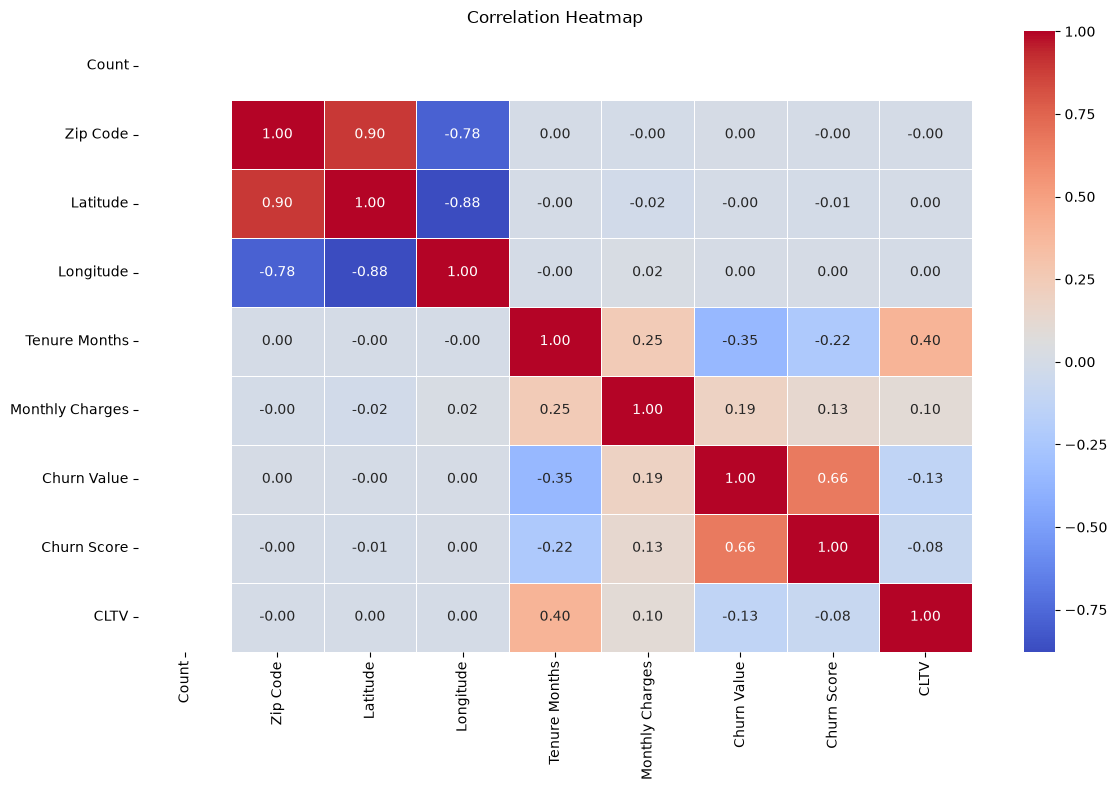

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


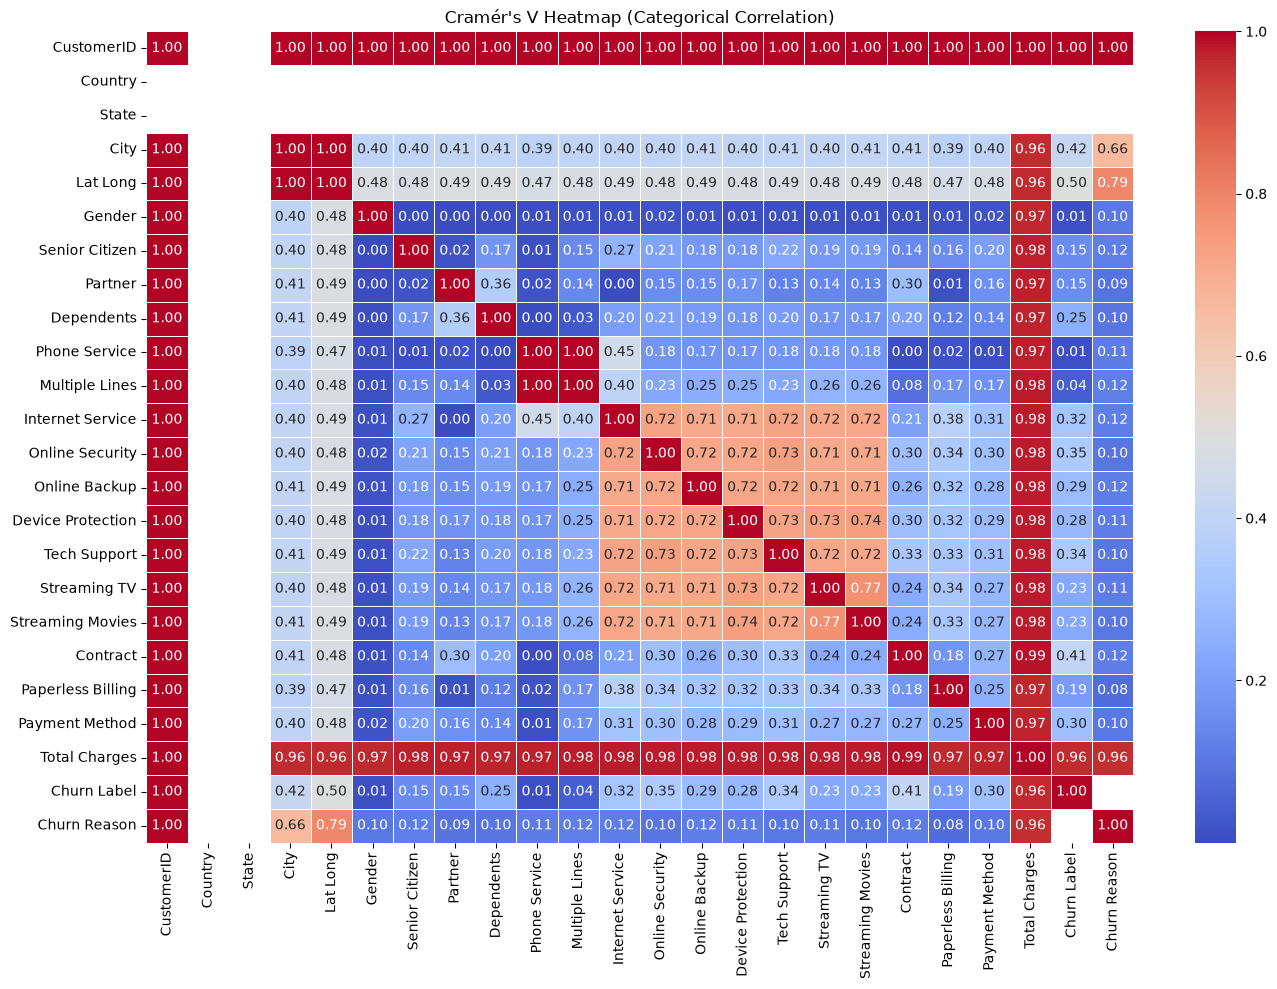

In [206]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = df.select_dtypes(include='object').columns.tolist()

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(14, 10))
sns.heatmap(
    cramers_matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Cramér's V Heatmap (Categorical Correlation)")
plt.tight_layout()
plt.show()
